In [1]:
import numpy as np
import pandas as pd
from scripts_env_v_4.variable_leverage_env_4 import agentDLVEnvV4
from scripts_env_v_4.utils import plot_metrics_v4, plot_episode_history_v2

In [2]:
df = pd.read_csv('wbtc_train_data_expanded.csv')
nav = df['nav'].values
nect_price = df['nect_price'].values
vol_token_price = df['wbtc_price'].values
volatile_part = df['wbtc_frac'].values

nav = nav[::4]
nect_price = nect_price[::4]
vol_token_price = vol_token_price[::4]
volatile_part = volatile_part[::4]

In [3]:
def naiveAgent(obs):
    leverage = obs[0]
    
    if leverage > 0.95 or leverage < 0.05:
        return 1
    else:
        return 0

==== USING V4 VERSION ====
action scale 1
primordial penalty 0.25
penalty damping 0.9
reward scale 1
reward bound 5
loss scale 0
liquidation penalty 0
risk coef 0
boundary reward scale 0
idle reward 0.05
rebalancing reward 0.2
extravagance penalty 0.1
doing nothing 98.79593107743409 %
action 1 1.2040689225659125 %
action 2 0.0 %
action 3 0.0 %


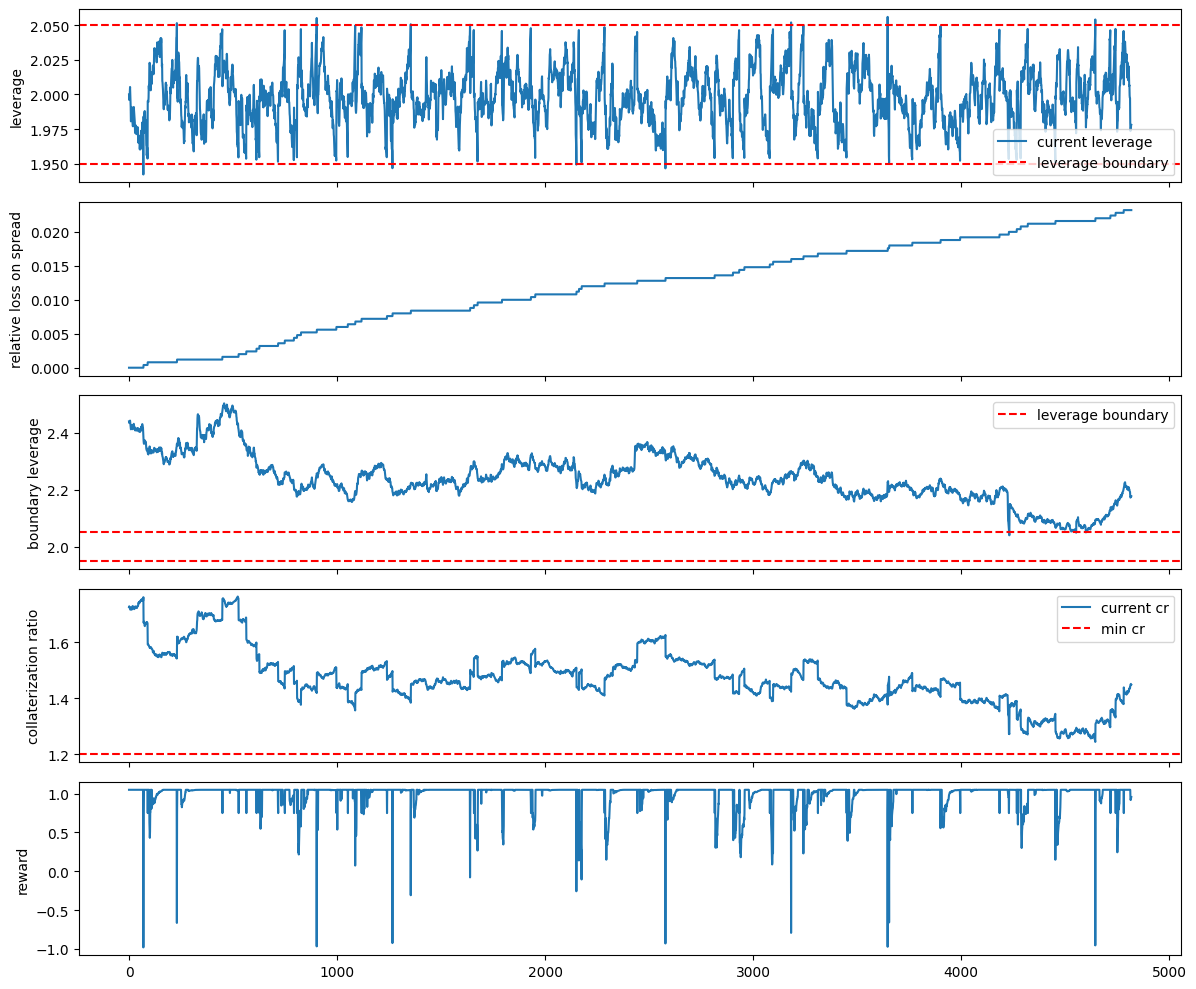

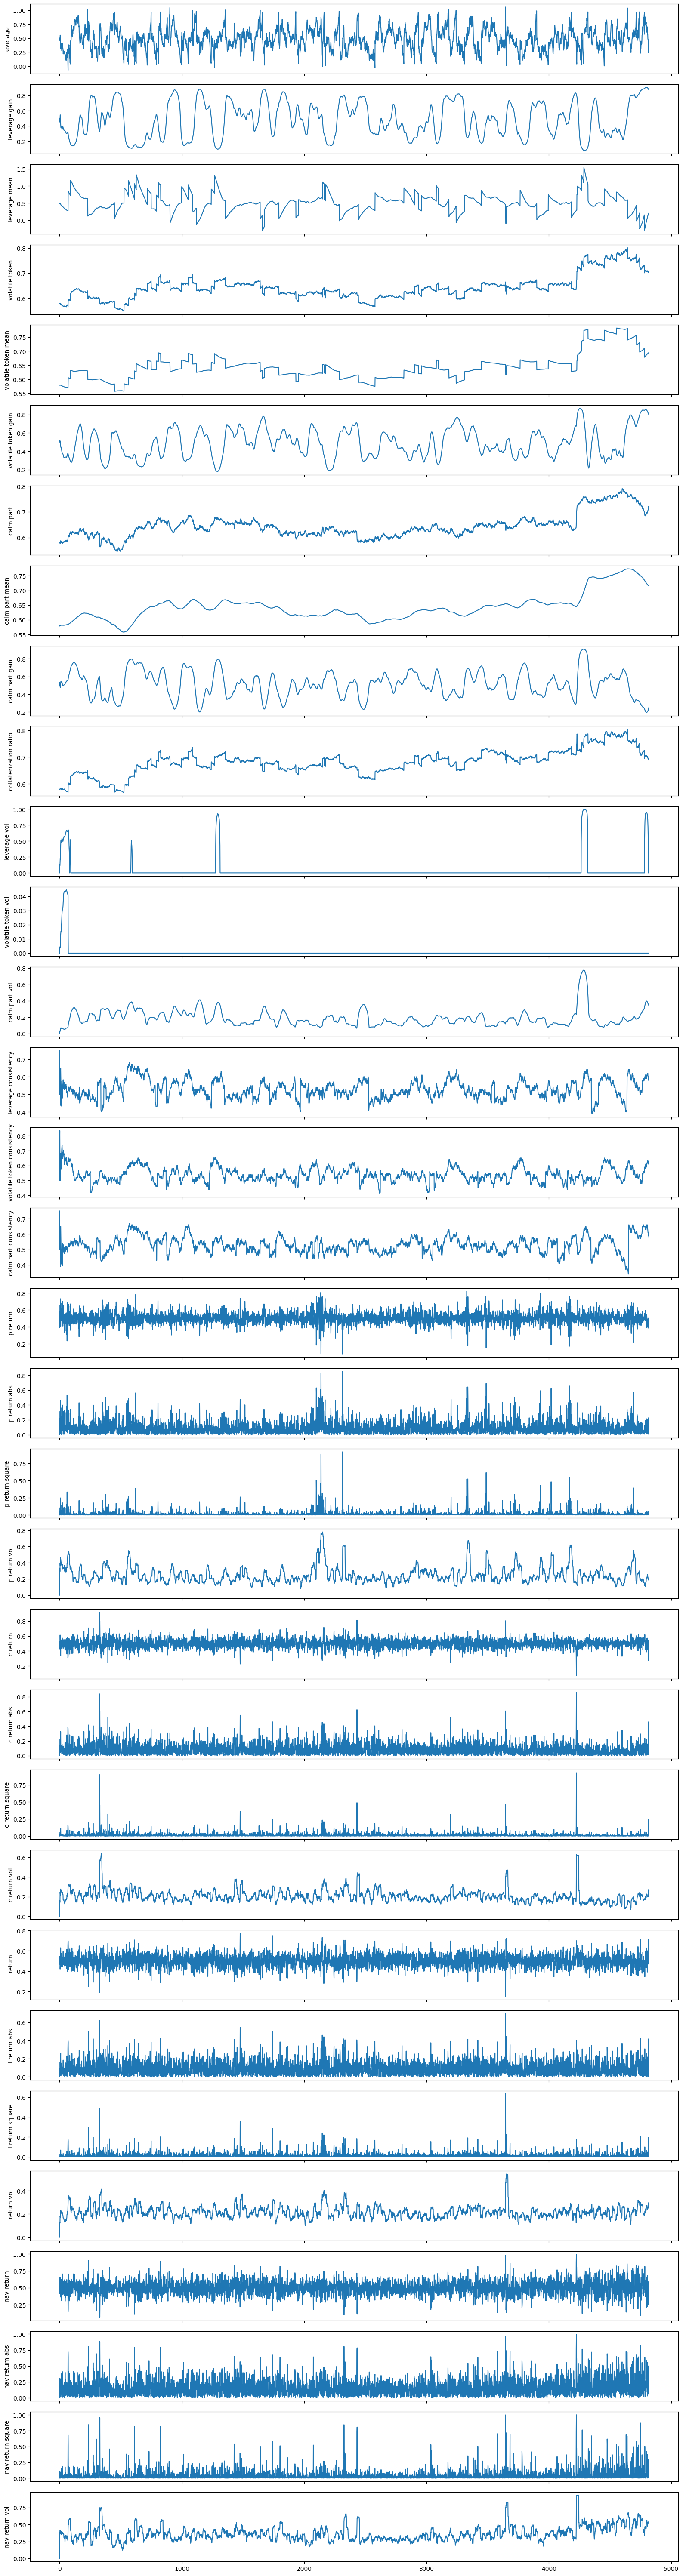

In [6]:
WIDTH = 0.1

eval_env = agentDLVEnvV4(
    nect_honey_price=nect_price,
    nav_in_honey=nav,
    vol_token_honey_price=vol_token_price,
    vol_part=volatile_part,
    is_training = False,
    is_mixed = True,
    is_reversed = True,
    top_leverage=2 + WIDTH/2,
    bottom_leverage=2 - WIDTH/2,
    seed = 400,
    is_syntetic = True,
    echo_penalty_scale=1,
    echo_penalty_damping=0.93
)

obs, _ = eval_env.reset()
done = False

while not done:
    action = naiveAgent(obs)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

history = info['episode_history']
history_metrics = info['episode_metrics']
economic_metrics = info['episode_economics']
t_l = info['top leverage']
b_l = info['bottom leverage']
not_doing = info.get('0 action')  
action_1 = info.get('0.5 rebalancing') 
action_2 = info.get('0.75 rebalancing') 
action_3 = info.get('0.25 rebalancing') 

print('doing nothing', not_doing*100, '%')
print('action 1', action_1*100, '%')
print('action 2', action_2*100, '%')
print('action 3', action_3*100, '%')

plot_episode_history_v2(history, t_l, b_l)
plot_metrics_v4(history_metrics)
#plot_economic_metrics(economic_metrics, t_l, b_l)

In [5]:
print(eval_env.seed)

400
